In [1]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X = df['age'].values
y = df['charges'].values

In [5]:
X = X.reshape(-1,1)
y = y.reshape(-1,1)

In [6]:
X_b = np.c_[np.ones((len(X),1)), X]

In [7]:
m = len(X)

theta = np.zeros((2,1))

learning_rate = 0.0001

iterations = 5000

In [8]:
cost_history = []

for i in range(iterations):

    y_pred = X_b @ theta

    error = y_pred - y

    gradient = (1/m) * (X_b.T @ error)

    theta = theta - learning_rate * gradient

    cost = (1/(2*m)) * np.sum(error**2)

    cost_history.append(cost)

In [9]:
print("Theta Values:")
print(theta)

Theta Values:
[[181.94448019]
 [325.17884841]]


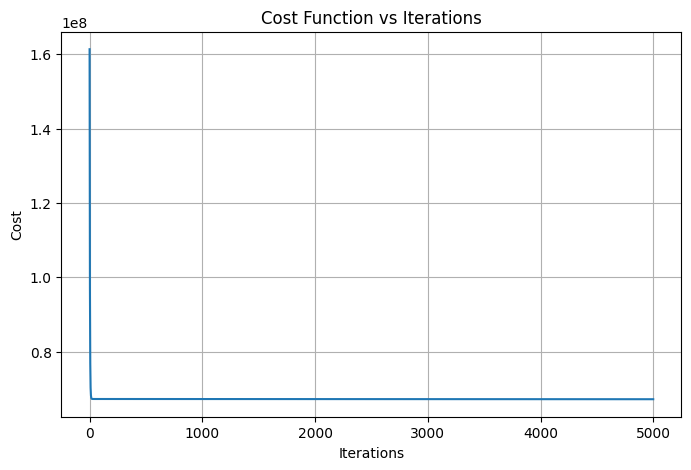

In [10]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.title("Cost Function vs Iterations")

plt.grid(True)

plt.show()

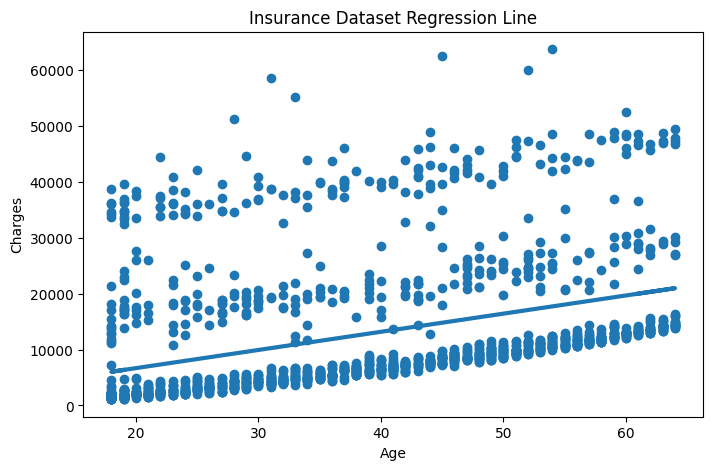

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(X,y)

plt.plot(X,
         X_b@theta,
         linewidth=3)

plt.xlabel("Age")

plt.ylabel("Charges")

plt.title("Insurance Dataset Regression Line")

plt.show()

In [12]:
theta_normal = np.linalg.inv(
    X_b.T @ X_b
) @ X_b.T @ y

print(theta_normal)

[[3165.88500606]
 [ 257.72261867]]


In [13]:
print("Gradient Descent Theta:")
print(theta)

print("\nNormal Equation Theta:")
print(theta_normal)

Gradient Descent Theta:
[[181.94448019]
 [325.17884841]]

Normal Equation Theta:
[[3165.88500606]
 [ 257.72261867]]


In [14]:
predicted = X_b @ theta

comparison = pd.DataFrame({

    "Actual": y.flatten(),

    "Predicted": predicted.flatten()

})

comparison.head(10)

,Actual,Predicted
0,16884.92400,6360.342600
1,1725.55230,6035.163752
2,4449.46200,9286.952236
3,21984.47061,10912.846478
4,3866.85520,10587.667629
5,3756.62160,10262.488781
6,8240.58960,15140.171507
7,7281.50560,12213.561871
8,6406.41070,12213.561871
9,28923.13692,19692.675385


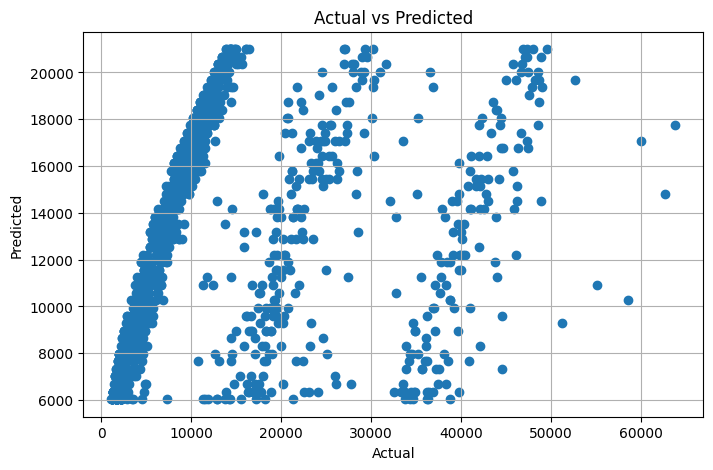

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y,predicted)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [16]:
new_age = np.array([
    [31],
    [46],
    [37],
    [37],
    [60]
])

In [17]:
new_X = np.c_[

    np.ones((len(new_age),1)),

    new_age

]

In [18]:
new_predictions = new_X @ theta

print(new_predictions)

[[10262.48878088]
 [15140.17150701]
 [12213.56187133]
 [12213.56187133]
 [19692.67538474]]


In [19]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y,
    predicted
)

rmse = np.sqrt(mse)

print("RMSE:",rmse)

RMSE: 11595.412713377267
